In [1]:
from trading.backtest.strategy import process_symbol
from trading.utils.plots import plot_trades_scatter
import pandas as pd

## Backtest

In [8]:
date = "2025-01-02"
fmt   = "%Y-%m-%d"

vBOT = "0.0.1"

INITIAL_CAPITAL = 100_000  
capital = INITIAL_CAPITAL 
amount_per_trade = 1_000

ticks = ["BTCUSDT", "XRPUSDT", "ETHUSDT"]

In [9]:
# Backtesting
df_dict = {}

results = [process_symbol(symbol, date, fmt, "15m", 1, 8, ret_data=True) for symbol in ticks]
ops = []
for result, df_after in results:
    if result is not None:
        ops.append(result)
        symbol = result['symbol']
        df_dict[symbol] = df_after
    
df = pd.DataFrame(ops)

if df.empty:
    print(f"No operations launched at {date}\n")
    raise Exception("Empty DataFrame.")
else:
    print(f"{len(df)} operations launched at {date}\n")
    
df["version"] = vBOT
df["started_at"] = date
df['capital'] = 0.0
df['leverage'] = 1
df['result'] = df['real_pnl'].apply(lambda x: 'WON' if x > 0 else ('LOST' if x < 0 else None))
    
daily_pnl = df["real_pnl"].sum()

for idx, row in df.iterrows():
    capital += row['real_pnl']
    df.loc[idx, "capital"] = capital
print(f"Capital actualizado tras {date}: {capital:.2f}")

print("Completed!\n")


3 operations launched at 2025-01-02

Capital actualizado tras 2025-01-02: 99987.74
Completed!



## Results

In [10]:
display(df)

,symbol,side,qty,amount,stoploss,takeprofit,entry_time,exit_time,duration,entry_price,exit_price,pnl,real_pnl,closed_by,version,started_at,capital,leverage,result
0,BTCUSDT,SELL,0.010608,1000.0,95208.075210,93322.766790,2025-01-02 03:31:00,2025-01-02 03:23:00,-8,94265.42100,95208.075210,-10.0,-10.752,stoploss,0.0.1,2025-01-02,99989.248,1,LOST
1,XRPUSDT,BUY,450.736729,1000.0,2.196404,2.240776,2025-01-02 05:49:00,2025-01-02 05:48:00,-1,2.21859,2.240776,10.0,9.248,takeprofit,0.0.1,2025-01-02,99998.496,1,WON
2,ETHUSDT,SELL,0.302319,1000.0,3340.837701,3274.682499,2025-01-02 05:25:00,2025-01-02 05:24:00,-1,3307.76010,3340.837701,-10.0,-10.752,stoploss,0.0.1,2025-01-02,99987.744,1,LOST


In [11]:
print("Max amount", "\n", "-"*30)
print(df['amount'].max())
print("\nClosed by counts", "\n", "-"*30)
print(df["closed_by"].value_counts())
print("\nResult counts", "\n", "-"*30)
print(df["result"].value_counts())

Max amount 
 ------------------------------
1000.0

Closed by counts 
 ------------------------------
closed_by
stoploss      2
takeprofit    1
Name: count, dtype: int64

Result counts 
 ------------------------------
result
LOST    2
WON     1
Name: count, dtype: int64


#### Visualizar resultados

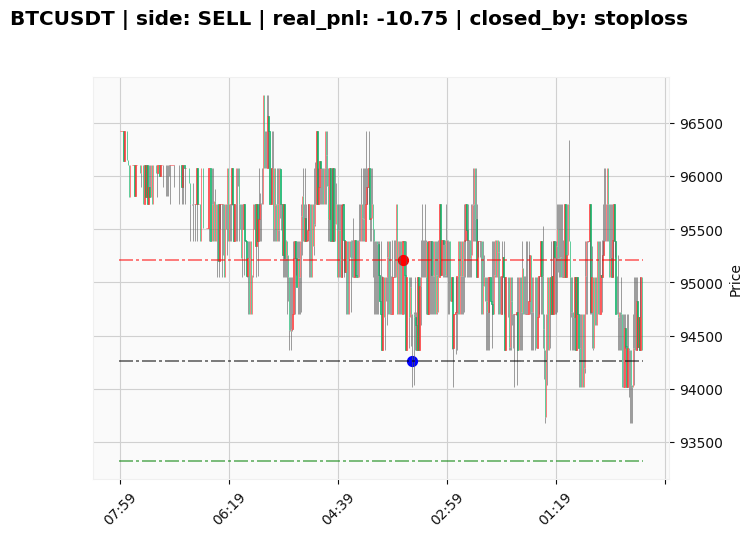

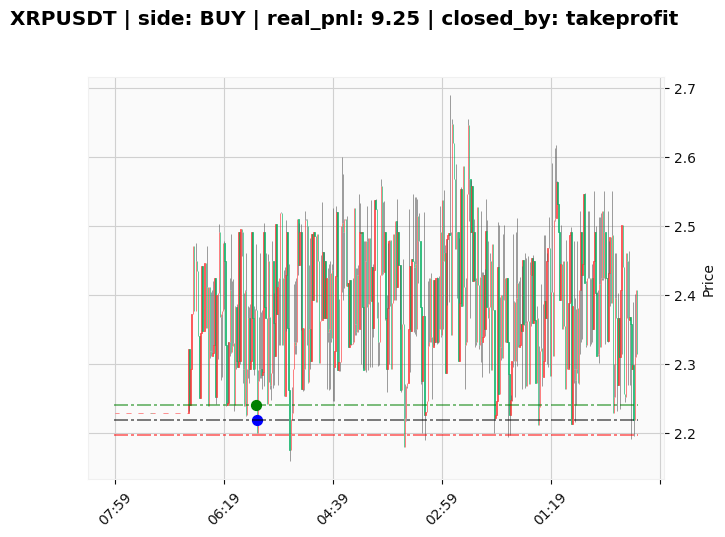

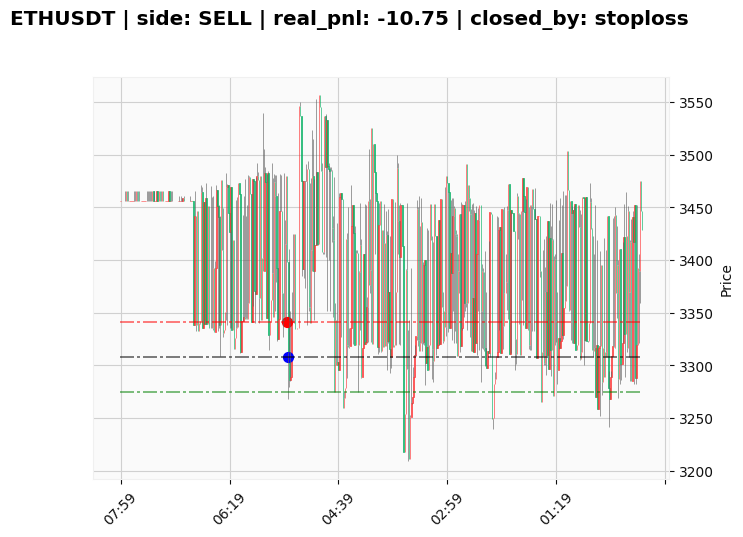

In [12]:
plot_trades_scatter(df, df_dict)